# Production-Grade Content Agent LLM Fine-Tuning for Multi-Agent Integration

This notebook fine-tunes a local instruction model for campaign content strategy classification and exports integration-ready artifacts for the project multi-agent system.

## Outputs
- LoRA adapter + tokenizer
- baseline vs fine-tuned evaluation package
- standalone inference wrapper
- integration stubs for `src/agents/tools` and `src/agents`

---
## Phase 1: Environment Setup & Reproducibility

### State-of-the-Art Context

**Why we fine-tune for this agent:**
Foundation models are general-purpose, but the content generation agent needs stable behavior on domain schemas and strategy labels. Fine-tuning improves output consistency, task-specific decision quality, and business controllability.

**Evolution:** Rules/heuristics → Classical ML → Transformer prompting → Instruction fine-tuning → Parameter-efficient adaptation (LoRA/QLoRA).

**Thesis contribution:** Evidence-backed adaptation under realistic compute constraints, with special focus on tracking conversion lift by strategy bucket and guarding against content fatigue.

In [1]:
import os
import re
import json
import time
import random
import warnings
import inspect
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import transformers
import peft
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, EarlyStoppingCallback
from peft import LoraConfig, TaskType, get_peft_model

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
print("Notebook started:", datetime.now().isoformat())
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("torch:", torch.__version__)

Notebook started: 2026-05-21T10:40:25.419707
transformers: 5.8.1
peft: 0.19.1
torch: 2.11.0


In [2]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed()

TOTAL_CORES = os.cpu_count() or 12
N_CORES = max(1, TOTAL_CORES - 1)
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
torch.set_num_threads(N_CORES)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)
print(f"CPU cores: {TOTAL_CORES} (using {N_CORES})")
print("Torch threads:", torch.get_num_threads())

Device: mps
CPU cores: 12 (using 11)
Torch threads: 11


In [3]:
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

EXPERIMENT_NAME = "content_llm_production"
ARTIFACT_DIR = PROJECT_ROOT / "experimentation" / "artifacts" / EXPERIMENT_NAME
FINAL_MODEL_DIR = ARTIFACT_DIR / "final_model"
ADAPTER_DIR = FINAL_MODEL_DIR / "lora_adapter"
INTEGRATION_DIR = ARTIFACT_DIR / "integration"

for p in [ARTIFACT_DIR, FINAL_MODEL_DIR, ADAPTER_DIR, INTEGRATION_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "model_id": "Qwen/Qwen2.5-0.5B-Instruct",
    "local_model_path": str(PROJECT_ROOT / "models" / "qwen2.5-0.5b-instruct-q5_0.gguf"),
    "model_source": "hf_only",
    "hf_cache_dir": str(PROJECT_ROOT / "models" / "hf_cache"),
    "hf_token_env": "HF_TOKEN",
    "max_length": 384,
    "gen_max_new_tokens": 40,
    "train_batch_size": 1,
    "eval_batch_size": 8,
    "gradient_accumulation_steps": 8,
    "learning_rate": 2e-4,
    "weight_decay": 0.01,
    "num_epochs": 4,
    "max_steps": 400,
    "warmup_ratio": 0.05,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 2,
    "early_stopping_threshold": 0.0005,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "tokenize_num_proc": min(4, N_CORES),
    "dataloader_num_workers": 0,
    "max_raw_rows": 50000,
    "train_samples": 2500,
    "val_samples": 500,
    "test_samples": 700,
    "baseline_eval_samples": 220,
    "final_eval_samples": 700,
    "data_path": str(PROJECT_ROOT / "data" / "raw" / "campaigns" / "marketing_campaign.csv"),
}

STRATEGY_OUTPUT_KEY = "strategy"
print("Project root:", PROJECT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)
for k, v in CONFIG.items():
    print(f"  {k:28s}: {v}")

Project root: /Users/jatinder.singh/drive/ai_mkt
Artifact dir: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/content_llm_production
  model_id                    : Qwen/Qwen2.5-0.5B-Instruct
  local_model_path            : /Users/jatinder.singh/drive/ai_mkt/models/qwen2.5-0.5b-instruct-q5_0.gguf
  model_source                : local_only
  max_length                  : 384
  gen_max_new_tokens          : 40
  train_batch_size            : 1
  eval_batch_size             : 8
  gradient_accumulation_steps : 8
  learning_rate               : 0.0002
  weight_decay                : 0.01
  num_epochs                  : 4
  max_steps                   : 400
  warmup_ratio                : 0.05
  max_grad_norm               : 1.0
  early_stopping_patience     : 2
  early_stopping_threshold    : 0.0005
  lora_r                      : 16
  lora_alpha                  : 32
  lora_dropout                : 0.05
  tokenize_num_proc           : 8
  dataloader_num_workers      : 0
  max

---
## Phase 2: Data Quality Audit & Task Construction

In [4]:
data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(data_path)

df_raw = pd.read_csv(data_path, sep=";", encoding="utf-8-sig")
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
print("\nResponse distribution:")
print(df_raw["Response"].value_counts().to_string())

Shape: (2240, 29)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Response distribution:
Response
0    1906
1     334


Rows after remediation: 2216
Labels: ['DISCOUNT_REENGAGE', 'EDUCATIONAL_NURTURE', 'LOYALTY_UPSELL']
label
EDUCATIONAL_NURTURE    1035
DISCOUNT_REENGAGE       999
LOYALTY_UPSELL          182


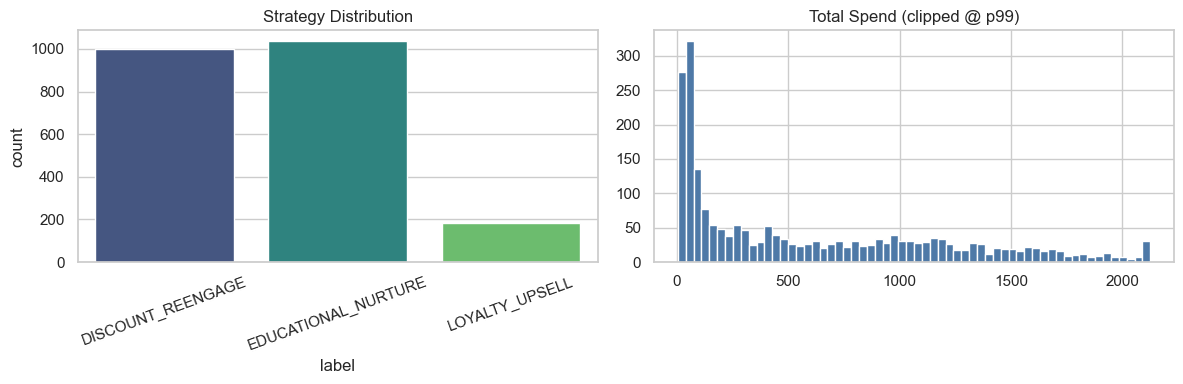

In [5]:
required_cols = ["Recency", "Income", "NumWebPurchases", "NumCatalogPurchases",
                 "NumStorePurchases", "Response", "MntWines", "MntMeatProducts", "MntGoldProds"]
df = df_raw.dropna(subset=required_cols).copy()
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df = df.dropna(subset=["Income"]).copy()


def strategy(row):
    spend = row.get("MntWines", 0) + row.get("MntMeatProducts", 0) + row.get("MntGoldProds", 0)
    high_spend = spend >= 700
    high_recency = row.get("Recency", 0) >= 50
    responded = int(row.get("Response", 0)) == 1

    if not responded and high_recency:
        return "DISCOUNT_REENGAGE"
    if responded and high_spend:
        return "LOYALTY_UPSELL"
    return "EDUCATIONAL_NURTURE"


df["label"] = df.apply(strategy, axis=1)

parts = []
per_class = max(250, CONFIG["max_raw_rows"] // 6)
for lbl, grp in df.groupby("label"):
    parts.append(grp.sample(min(len(grp), per_class), random_state=SEED))
df = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Rows after remediation:", len(df))
print("Labels:", sorted(df["label"].unique().tolist()))
print(df["label"].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="label", order=sorted(df["label"].unique()), ax=axes[0], palette="viridis")
axes[0].set_title("Strategy Distribution")
axes[0].tick_params(axis="x", rotation=20)
total_spend = df["MntWines"] + df.get("MntFruits", 0) + df["MntMeatProducts"] + df.get("MntFishProducts", 0) + df.get("MntSweetProducts", 0) + df["MntGoldProds"]
axes[1].hist(total_spend.clip(upper=total_spend.quantile(0.99)), bins=60, color="#4E79A7")
axes[1].set_title("Total Spend (clipped @ p99)")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "data_quality_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
label_list = sorted(df["label"].unique().tolist())


def format_input(row: pd.Series, labels: list[str]) -> str:
    total_spend = float(
        row.get("MntWines", 0) + row.get("MntFruits", 0) + row.get("MntMeatProducts", 0)
        + row.get("MntFishProducts", 0) + row.get("MntSweetProducts", 0) + row.get("MntGoldProds", 0)
    )
    return (
        f"Income={row['Income']}; Recency={row['Recency']}; TotalSpend={total_spend:.2f}; "
        f"WebPurchases={row['NumWebPurchases']}; CatalogPurchases={row['NumCatalogPurchases']}; "
        f"StorePurchases={row['NumStorePurchases']}; WebVisitsMonth={row['NumWebVisitsMonth']}; "
        f"DealsPurchases={row.get('NumDealsPurchases', 0)}; "
        f"Education={row.get('Education', 'Unknown')}; Marital_Status={row.get('Marital_Status', 'Unknown')}; "
        f"Kidhome={row.get('Kidhome', 0)}; Teenhome={row.get('Teenhome', 0)}; "
        f"PriorResponse={row['Response']}. "
        f"Choose one strategy from: {', '.join(labels)}."
    )


def format_target(label: str) -> str:
    return json.dumps({STRATEGY_OUTPUT_KEY: label}, ensure_ascii=False)


df_task = pd.DataFrame(
    {
        "instruction": "Select campaign strategy for this customer profile and reply with strict JSON.",
        "input_text": df.apply(lambda r: format_input(r, label_list), axis=1),
        "output_text": df["label"].map(format_target),
        "label": df["label"].astype(str),
    }
)

df_task = df_task.sample(min(len(df_task), CONFIG["max_raw_rows"]), random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(df_task, test_size=0.30, random_state=SEED, stratify=df_task["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])

train_df = train_df.sample(min(len(train_df), CONFIG["train_samples"]), random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(min(len(val_df), CONFIG["val_samples"]), random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(min(len(test_df), CONFIG["test_samples"]), random_state=SEED).reset_index(drop=True)

print(f"Train={len(train_df):,} Val={len(val_df):,} Test={len(test_df):,}")
print("Labels:", label_list)
print("\nSample row:")
print(train_df.iloc[0].to_dict())

Train=1,551 Val=332 Test=333
Labels: ['DISCOUNT_REENGAGE', 'EDUCATIONAL_NURTURE', 'LOYALTY_UPSELL']

Sample row:
{'instruction': 'Select campaign strategy for this customer profile and reply with strict JSON.', 'input_text': 'Income=53593.0; Recency=60; TotalSpend=480.00; WebPurchases=7; CatalogPurchases=2; StorePurchases=6; WebVisitsMonth=8; DealsPurchases=8; Education=PhD; Marital_Status=Together; Kidhome=1; Teenhome=1; PriorResponse=0. Choose one strategy from: DISCOUNT_REENGAGE, EDUCATIONAL_NURTURE, LOYALTY_UPSELL.', 'output_text': '{"strategy": "DISCOUNT_REENGAGE"}', 'label': 'DISCOUNT_REENGAGE'}


---
## Phase 3: Model Loading & Baseline Evaluation

In [7]:
def resolve_model_source(local_path: str, model_id: str, mode: str = "hf_only") -> str:
    local = Path(local_path)
    mode = (mode or "hf_only").lower()
    if mode == "local_only":
        if not local.exists():
            raise FileNotFoundError(f"Local model path not found: {local}")
        return str(local)
    if mode == "auto":
        return str(local) if local.exists() else model_id
    if mode == "hf_only":
        return model_id
    raise ValueError(f"Unsupported model_source mode: {mode}")


MODEL_REF = resolve_model_source(CONFIG["local_model_path"], CONFIG["model_id"], CONFIG["model_source"])
MODEL_BASE_REF = MODEL_REF
MODEL_GGUF_FILE = None

if MODEL_REF.lower().endswith(".gguf"):
    gguf_path = Path(MODEL_REF)
    MODEL_BASE_REF = str(gguf_path.parent)
    MODEL_GGUF_FILE = gguf_path.name
    try:
        import gguf  # noqa: F401
    except Exception as exc:
        raise ImportError("Install GGUF loader: pip install -U gguf") from exc

HF_CACHE_DIR = Path(CONFIG.get("hf_cache_dir", PROJECT_ROOT / "models" / "hf_cache"))
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR))
os.environ.setdefault("HF_HUB_CACHE", str(HF_CACHE_DIR / "hub"))

hf_token_env = CONFIG.get("hf_token_env", "HF_TOKEN")
hf_token = os.getenv(hf_token_env)
if hf_token and hf_token_env != "HF_TOKEN":
    os.environ["HF_TOKEN"] = hf_token

print("MODEL_REF:", MODEL_REF)
print("MODEL_BASE_REF:", MODEL_BASE_REF)
print("MODEL_GGUF_FILE:", MODEL_GGUF_FILE)
print("HF_CACHE_DIR:", HF_CACHE_DIR)
if hf_token:
    print(f"HF token found in env var: {hf_token_env}")

tok_kwargs = {"use_fast": True, "cache_dir": str(HF_CACHE_DIR)}
if MODEL_GGUF_FILE is not None:
    tok_kwargs["gguf_file"] = MODEL_GGUF_FILE

tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE_REF, **tok_kwargs)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def format_prompt(instruction: str, input_text: str) -> str:
    return (
        "### Instruction:\n"
        f"{instruction}\n\n"
        "### Input:\n"
        f"{input_text}\n\n"
        "### Response:\n"
    )


def build_sft_text(row: dict) -> tuple[str, str]:
    prompt = format_prompt(row["instruction"], row["input_text"])
    return prompt, prompt + row["output_text"]


def load_base_model(model_ref: str, gguf_file: str | None = None):
    dtype = torch.float16 if DEVICE.type in {"cuda", "mps"} else torch.float32
    kwargs = {
        "torch_dtype": dtype,
        "cache_dir": str(HF_CACHE_DIR),
    }
    if gguf_file is None:
        kwargs["low_cpu_mem_usage"] = True
    if gguf_file is not None:
        kwargs["gguf_file"] = gguf_file

    model = AutoModelForCausalLM.from_pretrained(model_ref, **kwargs)
    model = model.to(DEVICE)
    model.config.pad_token_id = tokenizer.pad_token_id
    return model


def generate_response(model, instruction: str, input_text: str) -> str:
    prompt = format_prompt(instruction, input_text)
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=CONFIG["max_length"])
    enc = {k: v.to(next(model.parameters()).device) for k, v in enc.items()}
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=CONFIG["gen_max_new_tokens"],
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
    new_ids = out[0][enc["input_ids"].shape[1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


def parse_prediction(text: str, labels: list[str]) -> tuple[str | None, bool]:
    m = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    if m:
        try:
            obj = json.loads(m.group(0))
            val = str(obj.get(STRATEGY_OUTPUT_KEY, "")).strip()
            if val in labels:
                return val, True
        except Exception:
            pass
    upper = text.upper()
    for lbl in labels:
        if lbl.upper() in upper:
            return lbl, False
    return None, False


def evaluate_model(model, df_eval: pd.DataFrame, labels: list[str], max_items: int, desc: str = "eval") -> dict:
    sample = df_eval.sample(min(max_items, len(df_eval)), random_state=SEED).reset_index(drop=True)
    y_true, y_pred_raw, schema_ok, latencies, outputs = [], [], [], [], []

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=desc):
        t0 = time.time()
        txt = generate_response(model, row["instruction"], row["input_text"])
        latencies.append((time.time() - t0) * 1000.0)

        pred, ok = parse_prediction(txt, labels)
        y_true.append(row["label"])
        y_pred_raw.append(pred)
        schema_ok.append(ok)
        outputs.append(txt)

    majority = sample["label"].value_counts().idxmax()
    y_pred = [p if p in labels else majority for p in y_pred_raw]

    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(p),
        "recall_macro": float(r),
        "f1_macro": float(f1),
        "schema_valid_rate": float(np.mean(schema_ok)),
        "unknown_rate": float(np.mean([v is None for v in y_pred_raw])),
        "latency_ms_mean": float(np.mean(latencies)),
        "latency_ms_p95": float(np.percentile(latencies, 95)),
    }

    return {
        "sample": sample,
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_raw": y_pred_raw,
        "schema_ok": schema_ok,
        "latencies": latencies,
        "outputs": outputs,
    }

MODEL_REF: /Users/jatinder.singh/drive/ai_mkt/models/qwen2.5-0.5b-instruct-q5_0.gguf
MODEL_BASE_REF: /Users/jatinder.singh/drive/ai_mkt/models
MODEL_GGUF_FILE: qwen2.5-0.5b-instruct-q5_0.gguf


In [8]:
base_model = load_base_model(MODEL_BASE_REF, gguf_file=MODEL_GGUF_FILE)
baseline = evaluate_model(base_model, test_df, label_list, CONFIG["baseline_eval_samples"], desc="baseline")

print("Baseline metrics:")
for k, v in baseline["metrics"].items():
    print(f"  {k:22s}: {v:.4f}")

print("\nBaseline report:")
print(classification_report(baseline["y_true"], baseline["y_pred"], zero_division=0))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Converting and de-quantizing GGUF tensors...:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

baseline:   0%|          | 0/220 [00:00<?, ?it/s]

Baseline metrics:
  accuracy              : 0.4409
  precision_macro       : 0.1470
  recall_macro          : 0.3333
  f1_macro              : 0.2040
  schema_valid_rate     : 0.0000
  unknown_rate          : 0.0000
  latency_ms_mean       : 1060.9114
  latency_ms_p95        : 1449.5568

Baseline report:
                     precision    recall  f1-score   support

  DISCOUNT_REENGAGE       0.44      1.00      0.61        97
EDUCATIONAL_NURTURE       0.00      0.00      0.00       105
     LOYALTY_UPSELL       0.00      0.00      0.00        18

           accuracy                           0.44       220
          macro avg       0.15      0.33      0.20       220
       weighted avg       0.19      0.44      0.27       220



---
## Phase 4: LoRA Fine-Tuning with Production Controls

In [23]:
train_ds = Dataset.from_pandas(train_df[["instruction", "input_text", "output_text", "label"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[["instruction", "input_text", "output_text", "label"]].reset_index(drop=True))


def preprocess(example):
    prompt, full_text = build_sft_text(example)
    tok_full = tokenizer(full_text, truncation=True, max_length=CONFIG["max_length"], padding="max_length")
    tok_prompt = tokenizer(prompt, add_special_tokens=False)

    labels = tok_full["input_ids"].copy()
    prompt_len = min(len(tok_prompt["input_ids"]), CONFIG["max_length"])
    for i in range(prompt_len):
        labels[i] = -100

    labels = [(-100 if tid == tokenizer.pad_token_id else lab) for tid, lab in zip(tok_full["input_ids"], labels)]
    tok_full["labels"] = labels
    return tok_full


print(f"Tokenizing with num_proc={CONFIG['tokenize_num_proc']}")
train_tok = train_ds.map(preprocess, num_proc=CONFIG["tokenize_num_proc"])
val_tok = val_ds.map(preprocess, num_proc=CONFIG["tokenize_num_proc"])

keep_cols = ["input_ids", "attention_mask", "labels"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
val_tok = val_tok.remove_columns([c for c in val_tok.column_names if c not in keep_cols])

train_tok.set_format(type="torch")
val_tok.set_format(type="torch")
print(train_tok)

Tokenizing with num_proc=8


Map (num_proc=8):   0%|          | 0/1551 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/332 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1551
})


In [10]:
ft_model = load_base_model(MODEL_BASE_REF, gguf_file=MODEL_GGUF_FILE)

candidate_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
    "Wqkv", "c_attn", "c_proj",
]
module_names = {n.split(".")[-1] for n, _ in ft_model.named_modules()}
lora_targets = [m for m in candidate_modules if m in module_names]
if not lora_targets:
    lora_targets = ["q_proj", "v_proj"]

lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=lora_targets,
    bias="none",
)

ft_model = get_peft_model(ft_model, lora_cfg)
ft_model.print_trainable_parameters()
print("LoRA targets:", lora_targets)

Converting and de-quantizing GGUF tensors...:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 638,965,632 || trainable%: 1.3769
LoRA targets: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


In [24]:
set_seed()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

sig = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
kwargs = {
    "output_dir": str(ARTIFACT_DIR / "checkpoints"),
    "per_device_train_batch_size": CONFIG["train_batch_size"],
    "per_device_eval_batch_size": max(1, CONFIG["train_batch_size"]),
    "gradient_accumulation_steps": CONFIG["gradient_accumulation_steps"],
    "learning_rate": CONFIG["learning_rate"],
    "num_train_epochs": CONFIG["num_epochs"],
    "weight_decay": CONFIG["weight_decay"],
    "warmup_ratio": CONFIG["warmup_ratio"],
    "max_grad_norm": CONFIG["max_grad_norm"],
    "logging_steps": 20,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "save_total_limit": 2,
    "seed": SEED,
    "report_to": [],
    "dataloader_num_workers": CONFIG["dataloader_num_workers"],
}

if CONFIG["max_steps"] and CONFIG["max_steps"] > 0:
    kwargs["max_steps"] = CONFIG["max_steps"]

opt = {
    "overwrite_output_dir": True,
    "eval_strategy": "epoch",
    "evaluation_strategy": "epoch",
    "bf16": False,
    "fp16": DEVICE.type == "cuda",
    "use_mps_device": DEVICE.type == "mps",
}
for k, v in opt.items():
    if k in sig:
        kwargs[k] = v

unsupported = sorted([k for k in kwargs if k not in sig])
for k in unsupported:
    kwargs.pop(k)
if unsupported:
    print("Dropping unsupported TrainingArguments keys:", unsupported)

train_args = TrainingArguments(**kwargs)

trainer_kwargs = {
    "model": ft_model,
    "args": train_args,
    "train_dataset": train_tok,
    "eval_dataset": val_tok,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=CONFIG["early_stopping_patience"],
            early_stopping_threshold=CONFIG["early_stopping_threshold"],
        )
    ],
}

trainer_sig = set(inspect.signature(Trainer.__init__).parameters.keys())
if "processing_class" in trainer_sig:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_sig:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)
print("Trainer ready.")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready.


In [12]:
start = time.time()
train_result = trainer.train()
train_minutes = (time.time() - start) / 60.0

print(f"Training completed in {train_minutes:.2f} minutes")
print("Epoch reached:", trainer.state.epoch)
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151643, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss
1,0.015331,0.010722
2,0.002940,0.004146


Training completed in 31.95 minutes
Epoch reached: 2.0618955512572534


TrainOutput(global_step=400, training_loss=0.04207174835726619, metrics={'train_runtime': 1916.2327, 'train_samples_per_second': 1.67, 'train_steps_per_second': 0.209, 'total_flos': 3704955174715392.0, 'train_loss': 0.04207174835726619, 'epoch': 2.0618955512572534})

---
## Phase 5: Evaluation, Overfitting Check, and Forgetting Analysis

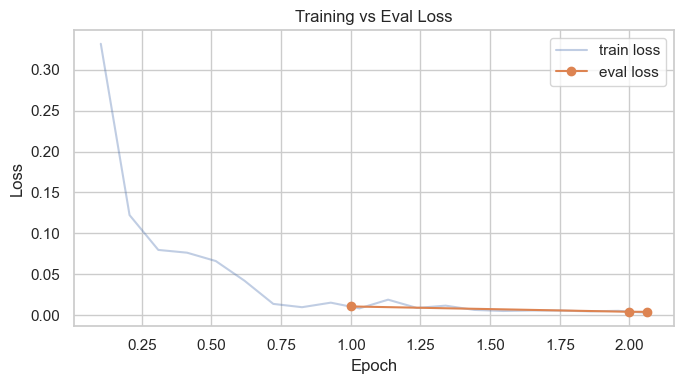

In [13]:
logs = trainer.state.log_history
train_points = [(e.get("epoch"), e.get("loss")) for e in logs if "loss" in e and "eval_loss" not in e]
eval_points = [e for e in logs if "eval_loss" in e]

if eval_points:
    eval_epochs = [e.get("epoch", i + 1) for i, e in enumerate(eval_points)]
    eval_losses = [e.get("eval_loss") for e in eval_points]

    fig, ax = plt.subplots(figsize=(7, 4))
    if train_points:
        xs = [x for x, _ in train_points if x is not None]
        ys = [y for _, y in train_points]
        ax.plot(xs, ys, alpha=0.35, label="train loss")
    ax.plot(eval_epochs, eval_losses, "o-", label="eval loss")
    ax.legend()
    ax.set_title("Training vs Eval Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

In [14]:
after = evaluate_model(trainer.model, test_df, label_list, CONFIG["final_eval_samples"], desc="after")
comparison = pd.DataFrame([baseline["metrics"], after["metrics"]], index=["before", "after"])
comparison.loc["improvement"] = comparison.loc["after"] - comparison.loc["before"]

print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nAfter report:")
print(classification_report(after["y_true"], after["y_pred"], zero_division=0))

# Forgetting on same baseline sample
after_same = evaluate_model(trainer.model, baseline["sample"], label_list, len(baseline["sample"]), desc="forget")
base_true = np.array(baseline["y_true"])
base_pred = np.array(baseline["y_pred"])
ft_pred = np.array(after_same["y_pred"])

base_correct = base_pred == base_true
ft_correct = ft_pred == base_true
forgotten = base_correct & ~ft_correct
forgetting_rate = float(forgotten.sum() / max(base_correct.sum(), 1))
print(f"\nForgetting rate: {forgetting_rate:.2%}")

after:   0%|          | 0/333 [00:00<?, ?it/s]

             accuracy  precision_macro  recall_macro  f1_macro  schema_valid_rate  unknown_rate  latency_ms_mean  latency_ms_p95
before         0.4409           0.1470        0.3333    0.2040             0.0000        0.0000        1060.9114       1449.5568
after          0.9820           0.9512        0.9676    0.9590             1.0000        0.0000         752.9560        958.6864
improvement    0.5411           0.8042        0.6343    0.7550             1.0000        0.0000        -307.9554       -490.8704

After report:
                     precision    recall  f1-score   support

  DISCOUNT_REENGAGE       1.00      1.00      1.00       150
EDUCATIONAL_NURTURE       0.99      0.97      0.98       155
     LOYALTY_UPSELL       0.87      0.93      0.90        28

           accuracy                           0.98       333
          macro avg       0.95      0.97      0.96       333
       weighted avg       0.98      0.98      0.98       333



forget:   0%|          | 0/220 [00:00<?, ?it/s]


Forgetting rate: 55.67%


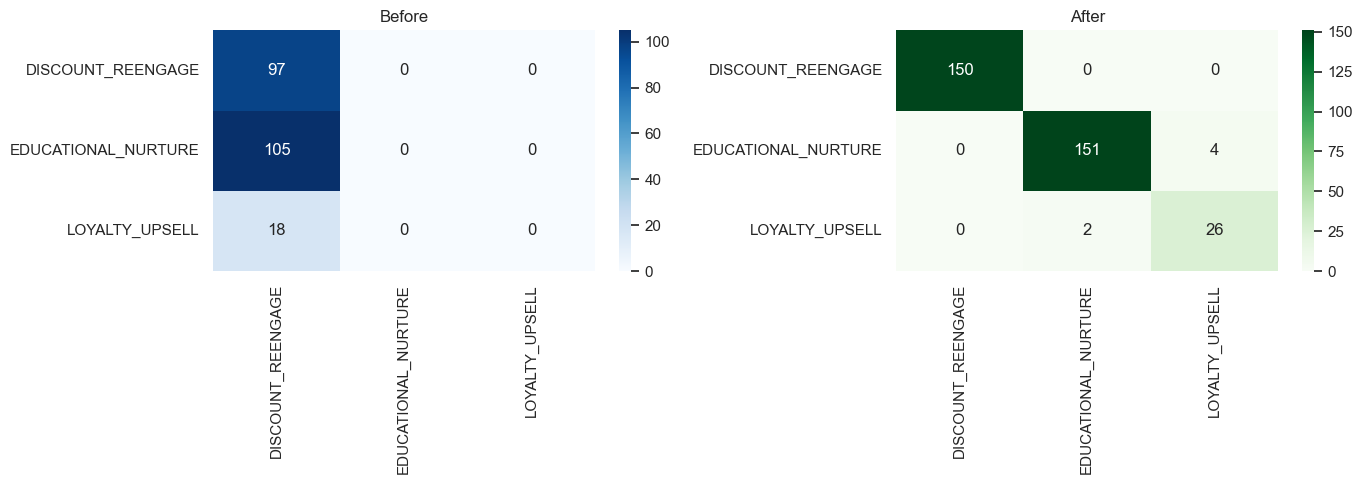

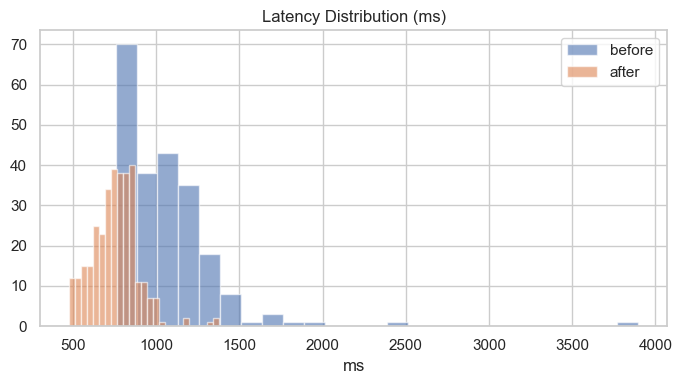

In [15]:
cm_before = confusion_matrix(baseline["y_true"], baseline["y_pred"], labels=label_list)
cm_after = confusion_matrix(after["y_true"], after["y_pred"], labels=label_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues", xticklabels=label_list, yticklabels=label_list, ax=axes[0])
axes[0].set_title("Before")
sns.heatmap(cm_after, annot=True, fmt="d", cmap="Greens", xticklabels=label_list, yticklabels=label_list, ax=axes[1])
axes[1].set_title("After")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(baseline["latencies"], bins=25, alpha=0.6, label="before")
ax.hist(after["latencies"], bins=25, alpha=0.6, label="after")
ax.legend()
ax.set_title("Latency Distribution (ms)")
ax.set_xlabel("ms")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "latency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
print("BEFORE")
print(classification_report(baseline["y_true"], baseline["y_pred"], zero_division=0))

print("AFTER")
print(classification_report(after["y_true"], after["y_pred"], zero_division=0))

BEFORE
                     precision    recall  f1-score   support

  DISCOUNT_REENGAGE       0.44      1.00      0.61        97
EDUCATIONAL_NURTURE       0.00      0.00      0.00       105
     LOYALTY_UPSELL       0.00      0.00      0.00        18

           accuracy                           0.44       220
          macro avg       0.15      0.33      0.20       220
       weighted avg       0.19      0.44      0.27       220

AFTER
                     precision    recall  f1-score   support

  DISCOUNT_REENGAGE       1.00      1.00      1.00       150
EDUCATIONAL_NURTURE       0.99      0.97      0.98       155
     LOYALTY_UPSELL       0.87      0.93      0.90        28

           accuracy                           0.98       333
          macro avg       0.95      0.97      0.96       333
       weighted avg       0.98      0.98      0.98       333



---
## Phase 6: Export Integration Artifacts

In [17]:
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

summary = {
    "experiment_name": EXPERIMENT_NAME,
    "timestamp": datetime.now().isoformat(),
    "labels": label_list,
    "device": str(DEVICE),
    "model_ref": MODEL_REF,
    "model_base_ref": MODEL_BASE_REF,
    "gguf_file": MODEL_GGUF_FILE,
    "adapter_dir": str(ADAPTER_DIR),
    "baseline_metrics": baseline["metrics"],
    "after_metrics": after["metrics"],
    "improvement": comparison.loc["improvement"].to_dict(),
    "forgetting_rate": forgetting_rate,
    "train_time_minutes": train_minutes,
}

with open(ARTIFACT_DIR / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

comparison.to_csv(ARTIFACT_DIR / "metrics_comparison.csv")
print("Saved adapter + summary files.")

Saved adapter + summary files.


In [18]:
wrapper_code = '"""Content Strategy LLM wrapper for multi-agent integration."""\n\nimport json\nimport re\nfrom typing import Any, Dict, List\n\nimport torch\nfrom transformers import AutoTokenizer, AutoModelForCausalLM\nfrom peft import PeftModel\n\n\nclass ContentStrategyLLMAgent:\n    """Inference wrapper for LoRA-adapted content strategy model."""\n\n    def __init__(\n        self,\n        base_model_ref: str,\n        adapter_path: str,\n        labels: List[str],\n        gguf_file: str | None = None,\n        device: str | None = None,\n        max_length: int = 384,\n        max_new_tokens: int = 40,\n    ):\n        if device is None:\n            if torch.backends.mps.is_available():\n                device = "mps"\n            elif torch.cuda.is_available():\n                device = "cuda"\n            else:\n                device = "cpu"\n\n        self.device = torch.device(device)\n        self.labels = labels\n        self.max_length = max_length\n        self.max_new_tokens = max_new_tokens\n\n        tok_kwargs: Dict[str, Any] = {"use_fast": True}\n        model_kwargs: Dict[str, Any] = {\n            "torch_dtype": torch.float16 if device in {"cuda", "mps"} else torch.float32,\n            "low_cpu_mem_usage": True\n        }\n        if gguf_file is not None:\n            tok_kwargs["gguf_file"] = gguf_file\n            model_kwargs["gguf_file"] = gguf_file\n\n        self.tokenizer = AutoTokenizer.from_pretrained(base_model_ref, **tok_kwargs)\n        if self.tokenizer.pad_token is None:\n            self.tokenizer.pad_token = self.tokenizer.eos_token\n\n        base = AutoModelForCausalLM.from_pretrained(base_model_ref, **model_kwargs)\n        model = PeftModel.from_pretrained(base, adapter_path)\n        self.model = model.to(self.device)\n        self.model.eval()\n\n    @staticmethod\n    def _format_prompt(input_text: str) -> str:\n        instruction = "Select campaign strategy for this customer profile and reply with strict JSON."\n        return (\n            "### Instruction:\\n"\n            f"{instruction}\\n\\n"\n            "### Input:\\n"\n            f"{input_text}\\n\\n"\n            "### Response:\\n"\n        )\n\n    def _parse(self, text: str) -> Dict[str, Any]:\n        match = re.search(r"\\{.*?\\}", text, flags=re.DOTALL)\n        if match:\n            raw = match.group(0)\n            try:\n                obj = json.loads(raw)\n                val = str(obj.get("strategy", "")).strip()\n                if val in self.labels:\n                    return {"strategy": val, "schema_valid": True}\n            except Exception:\n                pass\n\n        upper = text.upper()\n        for lbl in self.labels:\n            if lbl.upper() in upper:\n                return {"strategy": lbl, "schema_valid": False}\n\n        return {"strategy": None, "schema_valid": False}\n\n    def predict(self, input_text: str) -> Dict[str, Any]:\n        prompt = self._format_prompt(input_text)\n        enc = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=self.max_length)\n        enc = {k: v.to(self.device) for k, v in enc.items()}\n\n        with torch.no_grad():\n            out = self.model.generate(\n                **enc,\n                max_new_tokens=self.max_new_tokens,\n                do_sample=False,\n                eos_token_id=self.tokenizer.eos_token_id,\n                pad_token_id=self.tokenizer.pad_token_id,\n            )\n\n        new_ids = out[0][enc["input_ids"].shape[1]:]\n        text = self.tokenizer.decode(new_ids, skip_special_tokens=True).strip()\n        parsed = self._parse(text)\n\n        return {\n            "success": parsed["strategy"] is not None,\n            "strategy": parsed["strategy"],\n            "schema_valid": parsed["schema_valid"],\n            "raw_output": text,\n        }\n\n    def predict_batch(self, inputs: List[str]) -> List[Dict[str, Any]]:\n        return [self.predict(x) for x in inputs]\n'
wrapper_path = FINAL_MODEL_DIR / "content_agent_llm.py"
wrapper_path.write_text(wrapper_code)
print("Saved wrapper:", wrapper_path)

Saved wrapper: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/content_llm_production/final_model/content_agent_llm.py


In [19]:
import importlib.util

spec = importlib.util.spec_from_file_location("content_agent_llm", str(FINAL_MODEL_DIR / "content_agent_llm.py"))
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

agent = mod.ContentStrategyLLMAgent(
    base_model_ref=MODEL_BASE_REF,
    adapter_path=str(ADAPTER_DIR),
    labels=label_list,
    gguf_file=MODEL_GGUF_FILE,
    device=str(DEVICE),
    max_length=CONFIG["max_length"],
    max_new_tokens=CONFIG["gen_max_new_tokens"],
)

print("Wrapper smoke test:")
for txt in test_df["input_text"].head(3):
    out = agent.predict(txt)
    print({"strategy": out["strategy"], "schema_valid": out["schema_valid"]})

Converting and de-quantizing GGUF tensors...:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Wrapper smoke test:
{'strategy': 'DISCOUNT_REENGAGE', 'schema_valid': True}
{'strategy': 'DISCOUNT_REENGAGE', 'schema_valid': True}
{'strategy': 'EDUCATIONAL_NURTURE', 'schema_valid': True}


In [20]:
tools_stub = f"""
# Content Strategy LLM tools for the multi-agent system

from pathlib import Path
import sys
from typing import Dict, Any

project_root = Path(__file__).parent.parent.parent.parent
sys.path.insert(0, str(project_root))

from experimentation.artifacts.{EXPERIMENT_NAME}.final_model.content_agent_llm import ContentStrategyLLMAgent

_MODEL = None


def _load_model():
    global _MODEL
    if _MODEL is None:
        _MODEL = ContentStrategyLLMAgent(
            base_model_ref={MODEL_BASE_REF!r},
            adapter_path=str(project_root / "experimentation" / "artifacts" / {EXPERIMENT_NAME!r} / "final_model" / "lora_adapter"),
            labels={label_list!r},
            gguf_file={MODEL_GGUF_FILE!r},
        )
    return _MODEL


def predict_content_strategy_llm(input_text: str) -> Dict[str, Any]:
    try:
        model = _load_model()
        result = model.predict(input_text)
        return {{"success": result["success"], **result}}
    except Exception as e:
        return {{"success": False, "error": str(e)}}
"""

agent_stub = """
# Content strategy agent that uses the fine-tuned LLM tool

from typing import Any, Dict
from src.agents.tools.content_llm_tools import predict_content_strategy_llm


class ContentAgent:
    name = "content_agent"

    def process(self, payload: Dict[str, Any]) -> Dict[str, Any]:
        input_text = payload["input_text"]
        result = predict_content_strategy_llm(input_text)
        return {"agent": self.name, **result}
"""

(INTEGRATION_DIR / "content_llm_tools.py").write_text(tools_stub)
(INTEGRATION_DIR / "content_agent.py").write_text(agent_stub)

print("Saved integration stubs:")
print(" ", INTEGRATION_DIR / "content_llm_tools.py")
print(" ", INTEGRATION_DIR / "content_agent.py")

Saved integration stubs:
  /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/content_llm_production/integration/content_llm_tools.py
  /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/content_llm_production/integration/content_agent.py


In [21]:
model_card = f"""# Content Strategy LLM (LoRA) — Production Export

## Task
Campaign content strategy classification from customer marketing profile.

## Output Contract
Strict JSON: `{{"strategy": "<LABEL>"}}`

## Labels
{label_list}

## Results
- Baseline accuracy: {baseline['metrics']['accuracy']:.4f}
- Fine-tuned accuracy: {after['metrics']['accuracy']:.4f}
- Baseline macro F1: {baseline['metrics']['f1_macro']:.4f}
- Fine-tuned macro F1: {after['metrics']['f1_macro']:.4f}
- Schema valid rate: {after['metrics']['schema_valid_rate']:.4f}
- Forgetting rate: {forgetting_rate:.2%}

## Artifacts
- Adapter: `final_model/lora_adapter/`
- Wrapper: `final_model/content_agent_llm.py`
- Integration stubs: `integration/`
"""

(FINAL_MODEL_DIR / "MODEL_CARD.md").write_text(model_card)
print("Saved model card")

Saved model card


In [22]:
print("=" * 72)
print("EXPERIMENT COMPLETE")
print("=" * 72)
print("Artifact dir:", ARTIFACT_DIR)
for p in sorted(ARTIFACT_DIR.rglob("*")):
    if p.is_file():
        rel = p.relative_to(ARTIFACT_DIR)
        print(f"  {str(rel):58s} {p.stat().st_size / 1024:8.1f} KB")

EXPERIMENT COMPLETE
Artifact dir: /Users/jatinder.singh/drive/ai_mkt/experimentation/artifacts/content_llm_production
  checkpoints/checkpoint-388/README.md                            5.1 KB
  checkpoints/checkpoint-388/adapter_config.json                  1.1 KB
  checkpoints/checkpoint-388/adapter_model.safetensors        34411.2 KB
  checkpoints/checkpoint-388/chat_template.jinja                  2.5 KB
  checkpoints/checkpoint-388/optimizer.pt                     69002.8 KB
  checkpoints/checkpoint-388/rng_state.pth                       14.1 KB
  checkpoints/checkpoint-388/scheduler.pt                         1.4 KB
  checkpoints/checkpoint-388/tokenizer.json                   11159.1 KB
  checkpoints/checkpoint-388/tokenizer_config.json                0.4 KB
  checkpoints/checkpoint-388/trainer_state.json                   4.9 KB
  checkpoints/checkpoint-388/training_args.bin                    5.2 KB
  checkpoints/checkpoint-400/README.md                            5.1 KB
  chec